# Caso de uso: Churn y probabilidad

In [30]:
# Importar las librerias

import numpy as np
import pandas as pd
import seaborn as sns

import matplotlib.pyplot as plt

In [31]:
# Carga de datos

#data set de clientes que dejaron de pagar la cuota de su credito
df = pd.read_csv('https://raw.githubusercontent.com/Haroldgio28/Probabilidad_de_impago/main/data/case%202/Churn%20Modeling.csv')

In [32]:
df.head(3)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1


In [33]:
# Ahora se explora las caracteristicas del data set
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


### Descripcion

El dataset esta compuesto por 14 variables

| Variable        | Descripción                          | Tipo de variable          |
|-----------------|--------------------------------------|---------------------------|
| RowNumber       | Índice para el número de fila        | Cuantitativa discreta     |
| CustomerId      | Identificador único del cliente      | Cuantitativa discreta     |
| Surname         | Usuario del cliente                  | Cualitativa nominal       |
| CreditScore     | Puntaje del cliente                  | Cuantitativa discreta     |
| Geography       | Ubicación                            | Cualitativa nominal       |
| Gender          | Género                               | Cualitativa nominal       |
| Age             | Edad                                 | Cuantitativa discreta     |
| Tenure          | Tiempo con la cuenta                 | Cuantitativa discreta     |
| Balance         | Dinero en la cuenta                  | Cuantitativa continua     |
| NumOfProducts   | Número de productos con el banco     | Cuantitativa discreta     |
| HasCrCard       | Indicador si tiene tarjeta de crédito| Cuantitativa binaria      |
| IsActiveMember  | Indicador si es miembro activo       | Cuantitativa binaria      |
| EstimatedSalary | Salario aproximado                   | Cuantitativa continua     |
| Exited          | Cliente que dejó de pagar la cuota   | Cuantitativa binaria  |

## Probabilidad

In [34]:
# Calculo de casos totales donde el cleunte no pago su cuota
'''
Para este caso el valor:
1 = No pago la cuota
0 = Cumplio con el pago
'''
df['Exited'].sum()

#--> Como resultado tenemos 2.037 casos donde los clientes no cumplieron con el pago

np.int64(2037)

In [35]:
# Ahora se encuentra el numero total de los eventos en el data set

len(df['Exited'])

#--> Se encuentra que el numero total de eventos medidos son de 10.000 eventos

10000

In [36]:
# PROBABILIDAD FRECUENTISTA -> PROBABILIDAD GENERAL
'''
Este tipo de probabilidad hace alucion a cuantas veces se repite
un evento en un conjunto de datos
'''

df['Exited'].sum() / len(df['Exited'])*100

#--> Se encuntra que el evento en donde el cliente no pago su cuento representa
#   el 20.37% de todos los registros del evento

np.float64(20.369999999999997)

### Comparacion entre variables

In [37]:
# Se va a comprara las variables EXITED vs GEOGRAPHY

df['Geography'].value_counts(normalize=True)

#--> Se puede observar que Francia es el pais que tiene el 50.14% de los clientes

Geography
France     0.5014
Germany    0.2509
Spain      0.2477
Name: proportion, dtype: float64

In [38]:
# Cantidad de clientes por pais

df['Geography'].value_counts()

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

In [39]:
# Cantidad de casos de impago por pais

df.groupby('Geography')['Exited'].sum()

Geography
France     810
Germany    814
Spain      413
Name: Exited, dtype: int64

In [40]:
# Aqui se calcula la proporcian de casos de impago por pais

df.groupby('Geography')['Exited'].mean()*100

'''
Al calcular esta proporcion de no pagos o (impagos) por pais
Se encuentra que Germany tiene la tasa mas alta de no pagos con 32.44%
'''

'\nAl calcular esta proporcion de no pagos o (impagos) por pais\nSe encuentra que Germany tiene la tasa mas alta de no pagos con 32.44%\n'

<Axes: xlabel='Geography'>

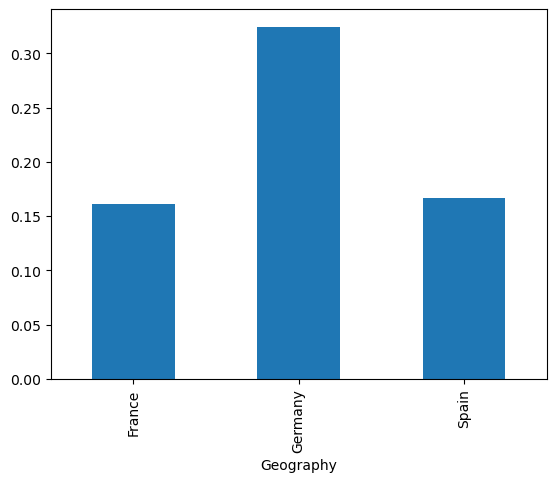

In [41]:
df.groupby('Geography')['Exited'].mean().plot(kind='bar')

In [42]:
# Ahora se va a comparar las variables GENERO vs EXITED

df['Gender'].value_counts()

Gender
Male      5457
Female    4543
Name: count, dtype: int64

In [43]:
df['Gender'].value_counts(normalize=True)*100

Gender
Male      54.57
Female    45.43
Name: proportion, dtype: float64

In [44]:
# Se encuentra el total de eventos por cada genero

df.groupby('Gender')['Exited'].sum()

Gender
Female    1139
Male       898
Name: Exited, dtype: int64

In [45]:
# Se encuentra la proporcion de no pago por parte de las mujeres

df.groupby('Gender')['Exited'].mean()*100

#--> Se ha encontrado que la proporcion de mujeres que no pagan es mayor a la de hombres

Gender
Female    25.071539
Male      16.455928
Name: Exited, dtype: float64

In [46]:
# hacemos un estudio de como se relacionan GEOGRAPHY con GENDER y la variables EXITED

df.groupby(['Geography','Gender'])['Exited'].mean()*100

Geography  Gender
France     Female    20.344980
           Male      12.713404
Germany    Female    37.552389
           Male      27.811550
Spain      Female    21.212121
           Male      13.112392
Name: Exited, dtype: float64

In [47]:
# AHora se compara las variables AGE y EXITED

df.Age.describe()

count    10000.000000
mean        38.921800
std         10.487806
min         18.000000
25%         32.000000
50%         37.000000
75%         44.000000
max         92.000000
Name: Age, dtype: float64

<Axes: xlabel='Exited', ylabel='Age'>

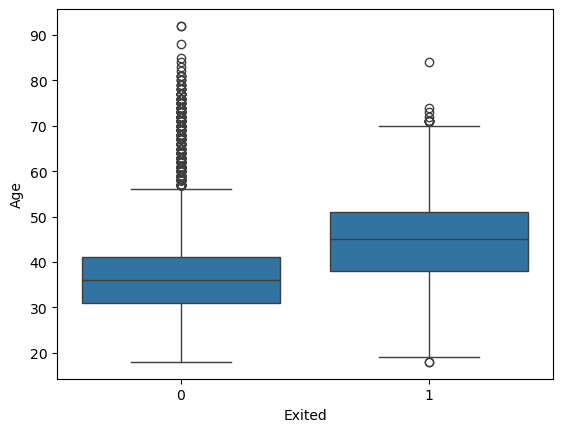

In [48]:
sns.boxplot(
    data= df,
    x = 'Exited',
    y= 'Age'
)

<Axes: xlabel='Exited', ylabel='Age'>

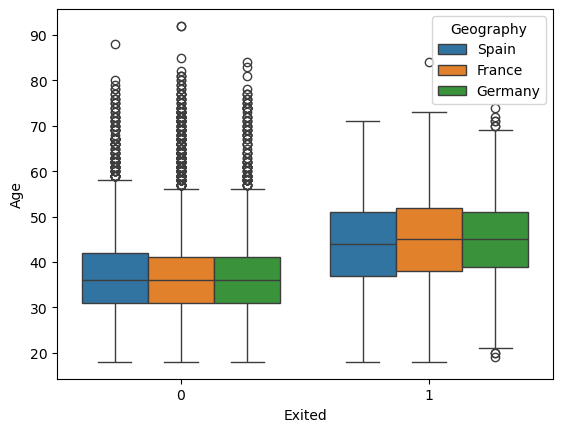

In [49]:
sns.boxplot(
    data= df,
    x = 'Exited',
    y= 'Age',
    hue='Geography'
)

In [50]:
# ¿ Hay relacion entre la edad y ubicacion ?

# ¿ Las coclusiones cambian si se analiza en funcion de edad, ubicacion y genero ?

## Discretizacion

La discretizacion consiste en convertir una variables en este caso cuantitativa continua (osea decimales) a unos valores que pueden ser categorizos o cuantitativos entre 0 y 1 normalmente

In [51]:
df['flag_joven_adulto'] = df['Age'].apply(
    lambda edad : 'Joven' if isinstance(edad, int) and 18 <= edad <=28
        else ('Adulto' if isinstance(edad, int) and edad > 28
            else ('No valido' if isinstance(edad, int)
                else 'Valor no valido')) 
)


df['flag_joven_adulto'].sample(5)

7877    Adulto
3345    Adulto
3528     Joven
8612    Adulto
2176    Adulto
Name: flag_joven_adulto, dtype: object

In [52]:
df['flag_joven_adulto'].value_counts()

flag_joven_adulto
Adulto    8707
Joven     1293
Name: count, dtype: int64

In [53]:
df['flag_joven_adulto'].value_counts(normalize=True)*100

flag_joven_adulto
Adulto    87.07
Joven     12.93
Name: proportion, dtype: float64

<Axes: xlabel='Exited', ylabel='Age'>

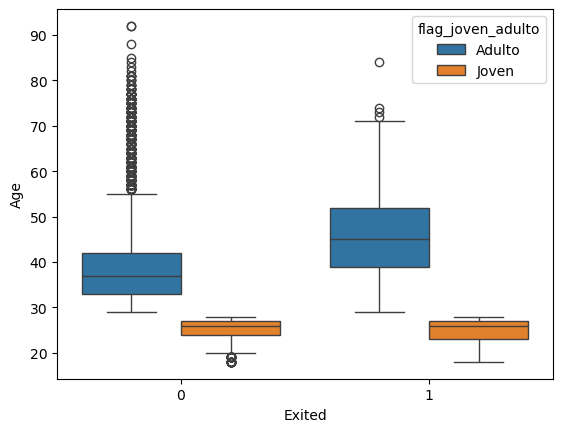

In [54]:
sns.boxplot(
    data= df,
    x = 'Exited',
    y= 'Age',
    hue='flag_joven_adulto'
)

# Story Telling

En este caso se va a utilizar las generaciones para poder tener un analisis mas granular o detallado del comportamiento de los clientes

In [55]:
generation_range = {
    'Greatest Generation' : (1900, 1924),
    'Silent Generation' : (1925, 1945),
    'Baby Boomers' : (1946, 1964),
    'Generation X' : (1965, 1980),
    'Millennials' : (1981, 1996),
    'Generation Z' : (1997, 2012),
    'Generation Alpha' : (2013, 2025)
}

In [56]:
generation_range.values()

dict_values([(1900, 1924), (1925, 1945), (1946, 1964), (1965, 1980), (1981, 1996), (1997, 2012), (2013, 2025)])

In [58]:
# Lo que se hace a continuacion es la imprtacion de la libreria dateTime
# Para el manejo de los años por parte de python

from datetime import datetime as dt

dt.now().year

2026

In [59]:
def categorize_generation(age, ranges):
    current_year = dt.now().year
    birth_year = current_year - age
    
    for generation, (start_year, end_year) in ranges.items():
        if start_year <= birth_year <= end_year:
            return generation
    return 'Unknown'

In [62]:
categorize_generation(25, generation_range)

'Generation Z'

In [63]:
# ahora voy a crear una nueva columna en el data set con la generacion a la que pertenece cada cliente

df['Generation'] = df['Age'].apply(lambda age: categorize_generation(age, generation_range))
df['Generation'].sample(5)

3721    Millennials
5392    Millennials
8119    Millennials
7428    Millennials
1913    Millennials
Name: Generation, dtype: object

In [ ]:
# Al utilizar el metodo value counts puedo saber cuantos clientes son de cada generacion
df['Generation'].value_counts()

Generation
Millennials          6248
Generation X         1700
Generation Z         1641
Baby Boomers          399
Silent Generation      12
Name: count, dtype: int64

In [ ]:
# En este punto lo puedo utilizar para ver la proporcion de cada genracion
df['Generation'].value_counts(normalize=True)*100

# vemos que los millennials son la generacion mas presente en este set de datos

Generation
Millennials          62.48
Generation X         17.00
Generation Z         16.41
Baby Boomers          3.99
Silent Generation     0.12
Name: proportion, dtype: float64

In [68]:
# Ahora voy a encontrar la proporcion de no pagos por cada generacion
df.groupby(['Generation'])['Exited'].mean().sort_index()*100

Generation
Baby Boomers         23.308271
Generation X         50.764706
Generation Z          7.556368
Millennials          15.300896
Silent Generation     8.333333
Name: Exited, dtype: float64

In [72]:
df.groupby(['Generation']).agg({
    'Age' : ['min', 'max'],
    'Exited' : ['mean']
}).sort_index()

Age        Exited
                  min max      mean
Generation                         
Baby Boomers       62  80  0.233083
Generation X       46  61  0.507647
Generation Z       18  29  0.075564
Millennials        30  45  0.153009
Silent Generation  81  92  0.083333

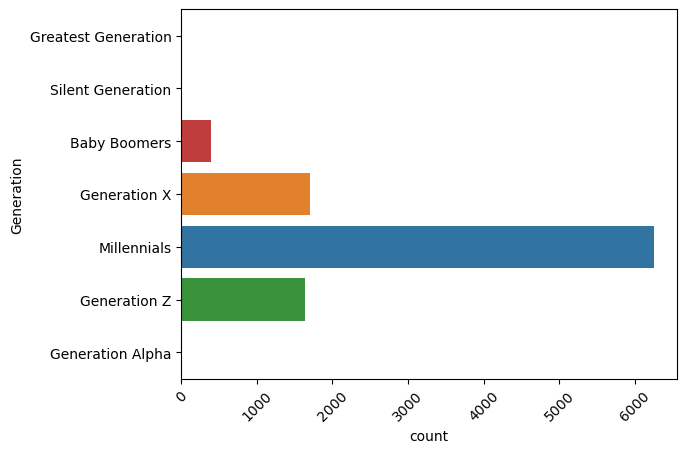

In [78]:
sns.countplot(
    data= df,
    y='Generation',
    hue='Generation',
    order=list(generation_range.keys())
)

plt.xticks(rotation=45)
plt.show()

<Axes: ylabel='Generation'>

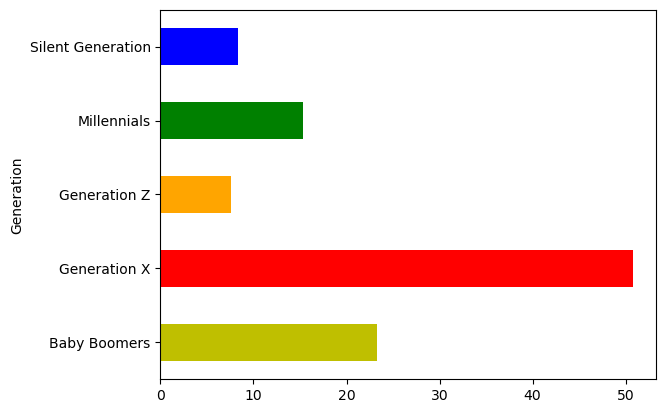

In [ ]:
colors = ['y','r','orange','green','blue','purple']

# Aqui voy a calcular la proporcion de no pago por cada generacion para graficarla
(df.groupby(['Generation'])['Exited'].mean().sort_index()*100).plot(kind='barh', color = colors)

# Al graficar de esta forma puedo saber la proporcion de impagos por cada generacion
'''
La generacion X es la que tiene mayores impagos
La generacion x representa cerca del 17% de los clientes
'''

In [82]:
# Se crea un data frame con cada generacion y su proporcion de no pago

df.groupby('Generation', as_index=False)['Exited'].mean()

,Generation,Exited
0,Baby Boomers,0.233083
1,Generation X,0.507647
2,Generation Z,0.075564
3,Millennials,0.153009
4,Silent Generation,0.083333


In [84]:
churn = (df.groupby('Generation')['Exited'].mean().sort_index())
churn

Generation
Baby Boomers         0.233083
Generation X         0.507647
Generation Z         0.075564
Millennials          0.153009
Silent Generation    0.083333
Name: Exited, dtype: float64

In [86]:
customers = df['Generation'].value_counts().sort_index()
customers

Generation
Baby Boomers          399
Generation X         1700
Generation Z         1641
Millennials          6248
Silent Generation      12
Name: count, dtype: int64

In [89]:
merge_df = churn.merge(customers, on='Generation')
merge_df['clientes_churn'] = merge_df['Exited'] * merge_df['count']
merge_df['impacto_usd'] = merge_df['clientes_churn'] * 1000
merge_df = merge_df.sort_values('impacto_usd')
print(merge_df.head())

AttributeError: 'Series' object has no attribute 'merge'